## Decision Trees & Information Gain

#### 1. What is a Decision Tree?
A **Decision Tree** is a supervised machine learning algorithm used for:
- Classification
- Regression

It works by **splitting data step-by-step** based on feature values until a decision (class/output) is reached.

Structure:
- **Root Node** → first split
- **Decision Nodes** → internal splits
- **Leaf Nodes** → final output (prediction)

Example:
If `Weather = Sunny` → Play  
If `Weather = Rainy` → Don’t Play

---

#### 2. Why Do We Need a Splitting Criterion?
At each node, the decision tree must decide:
> Which feature should I split on?

To answer this, we measure:
- How **uncertain** the data is
- How much a split **reduces uncertainty**

This is where **Entropy** and **Information Gain** come in.

---

#### 3. Entropy (Measure of Uncertainty)

##### Definition:
**Entropy** measures how mixed or impure the data is.

- High entropy → more randomness
- Low entropy → more purity

##### Formula:
Entropy(S) = − Σ pᵢ log₂(pᵢ)

Where:
- pᵢ = probability of class i

---

##### Entropy Values:
| Situation | Entropy |
|---------|--------|
| All data in one class | 0 (No uncertainty) |
| Equal mix of classes | Maximum entropy |
| More imbalance | Lower entropy |

---

##### Example:
If a dataset has:
- 8 Yes
- 2 No

p(Yes) = 0.8  
p(No) = 0.2  

Entropy = −(0.8 log₂ 0.8 + 0.2 log₂ 0.2)

---

#### 4. Information Gain (Reduction in Uncertainty)

##### Definition:
**Information Gain (IG)** measures how much entropy decreases after a split.

It tells us:
> How good is this feature for splitting?

---

##### Formula:
Information Gain(S, A) =  
Entropy(S) − Σ (|Sᵥ| / |S|) × Entropy(Sᵥ)

Where:
- S = parent dataset
- A = feature
- Sᵥ = subsets after split

---

##### Key Idea:
- High Information Gain → Better feature
- Decision Tree always chooses **maximum Information Gain**

---

#### 5. Why Information Gain is Important?
- Helps select the **best feature**
- Reduces randomness step by step
- Makes the tree **more accurate**
- Leads to faster and clearer decisions

---

#### 6. Decision Tree Algorithm (Using Information Gain)

1. Start with full dataset
2. Calculate **Entropy** of dataset
3. Calculate **Information Gain** for each feature
4. Choose feature with **highest IG**
5. Split the data
6. Repeat steps until:
   - All data is pure OR
   - No features remain

---

#### 7. Advantages of Decision Trees
- Easy to understand & visualize
- No need for feature scaling
- Works with categorical & numerical data
- Mimics human decision making

---

#### 8. Disadvantages
- Can overfit data
- Sensitive to noise
- Greedy algorithm (local optimum)
- Small data change → different tree

---

#### 9. Entropy vs Information Gain (Quick Comparison)

| Entropy | Information Gain |
|-------|----------------|
| Measures uncertainty | Measures reduction in uncertainty |
| Used before split | Used to choose best split |
| Lower is better | Higher is better |

---

#### 10. Real-World Example
Spam Detection:
- Initial data → High entropy
- Split on "Contains word FREE?"
- Entropy reduces
- Information Gain is high
→ Good splitting feature

---

#### 11. Key Exam / Interview Points
- Entropy = uncertainty
- Information Gain = entropy reduction
- Decision Trees choose max IG
- Entropy range: 0 to log₂(classes)
- Greedy, top-down algorithm

---

#### 12. One-Line Summary
**Decision Trees use Information Gain to reduce Entropy step-by-step and make accurate decisions.**


### Coding Exercises

#### 1. Create a small toy dataset manually (10–12 rows) with:
```
• 2–3 features
• binary class label

In [1]:
import csv

def load_play_tennis_csv(filepath):
    X = []
    y = []

    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            try:
                X.append([
                    row["outlook"],
                    row["temp"],
                    row["humidity"],
                    row["wind"]
                ])
                y.append(row["play"])
            except:
                continue

    return X, y


X, y = load_play_tennis_csv("play_tennis.csv")
print(X[:2])
print(y[:2])


[['Sunny', 'Hot', 'High', 'Weak'], ['Sunny', 'Hot', 'High', 'Strong']]
['No', 'No']


### 2. Write a function entropy(y) that:
```
• counts class proportions
• returns entropy value

In [2]:
import math
def entropy(y):
    total = len(y)
    count= {}
    for label in y:
        if label in count:
            count[label] += 1
        else:
            count[label] = 1
    print(count)
    ent = 0
    for count in count.values():
        p = count/ total
        ent -= p * math.log2(p)
    return ent

print("Entropy of full dataset:", entropy(y))

{'No': 5, 'Yes': 9}
Entropy of full dataset: 0.9402859586706311


### 3. Test entropy() for:
```
• perfectly balanced labels
• fully pure labels

In [3]:
# okay for this question we already write a function to find entropy in question 2.so

# for prefectly balanced label 
balanced = ['Yes','No','Yes','No']
print("The entropy of perfectly balanced labels is ",entropy(balanced))

# for fully pure labels 
pure = ['Yes','Yes','Yes','Yes']
print("The entropy of fully pure labels is ",entropy(pure))


{'Yes': 2, 'No': 2}
The entropy of perfectly balanced labels is  1.0
{'Yes': 4}
The entropy of fully pure labels is  0.0


### 4. Write a function split_dataset(X, y, feature, value) that splits data into:
```
• left group (feature <= value)
• right group (feature > value)

In [4]:
import csv
import math

# Step 1: Load CSV Dataset
def load_play_tennis_csv(filepath):
    
   # X: features (categorical)
   # y: labels (Yes/No)

    X = []
    y = []

    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            X.append([
                
                row["outlook"].strip(),
                row["temp"].strip(),
                row["humidity"].strip(),
                row["wind"].strip()
            ])
            y.append(row["play"].strip())
    return X, y

# Load dataset
X, y = load_play_tennis_csv("play_tennis.csv")
print("First 2 rows of X:", X[:2])
print("First 2 labels:", y[:2])

# Step 2: Encode Categorical Features and Labels
def encode_features(X):
    """
    Encode categorical features into numbers.
    Returns:
    X_encoded: encoded dataset
    encoders: list of dictionaries for mapping original values
    """
    encoders = []
    X_encoded = []

    # Encode each column
    for col in zip(*X):
        unique_vals = list(set(col))
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        encoders.append(mapping)

    # Apply encoding
    for row in X:
        encoded_row = [encoders[i][row[i]] for i in range(len(row))]
        X_encoded.append(encoded_row)

    return X_encoded, encoders

def encode_labels(y):
    """Encode 'Yes' as 1 and 'No' as 0"""
    mapping = {"No": 0, "Yes": 1}
    return [mapping[label] for label in y]

X_enc, encoders = encode_features(X)
y_enc = encode_labels(y)

print("Encoded rows:", X_enc)
print(encoders)
print("Encoded labels:", y_enc)

# Step 3: Entropy Function
def entropy(y):
    """
    Calculate entropy of a list of class labels.
    """
    total = len(y)
    counts = {}

    for label in y:
        counts[label] = counts.get(label, 0) + 1

    ent = 0
    for count in counts.values():
        p = count / total
        ent -= p * math.log2(p)

    return ent

# Test entropy()
print("Entropy of full dataset:", entropy(y_enc))
print("Entropy of pure labels [1,1,1]:", entropy([1,1,1]))
print("Entropy of balanced labels [1,0,1,0]:", entropy([1,0,1,0]))

# Step 4: Split Dataset Function
def split_dataset(X, y, feature, value):
    """
    Split X and y based on a feature and value:
    left: X[feature] <= value
    right: X[feature] > value
    """
    left_X, left_y = [], []
    right_X, right_y = [], []

    for i in range(len(X)):
        if X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    return left_X, left_y, right_X, right_y

# Example split on first feature (outlook encoded)
left_X, left_y, right_X, right_y = split_dataset(X_enc, y_enc, feature=0, value=1)
# print(left_X)
# print(right_X)
print("Left group labels:", left_y)
print("Right group labels:", right_y)


First 2 rows of X: [['Sunny', 'Hot', 'High', 'Weak'], ['Sunny', 'Hot', 'High', 'Strong']]
First 2 labels: ['No', 'No']
Encoded rows: [[1, 0, 0, 0], [1, 0, 0, 1], [0, 0, 0, 0], [2, 2, 0, 0], [2, 1, 1, 0], [2, 1, 1, 1], [0, 1, 1, 1], [1, 2, 0, 0], [1, 1, 1, 0], [2, 2, 1, 0], [1, 2, 1, 1], [0, 2, 0, 1], [0, 0, 1, 0], [2, 2, 0, 1]]
[{'Overcast': 0, 'Sunny': 1, 'Rain': 2}, {'Hot': 0, 'Cool': 1, 'Mild': 2}, {'High': 0, 'Normal': 1}, {'Weak': 0, 'Strong': 1}]
Encoded labels: [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0]
Entropy of full dataset: 0.9402859586706311
Entropy of pure labels [1,1,1]: 0.0
Entropy of balanced labels [1,0,1,0]: 1.0
Left group labels: [0, 0, 1, 1, 0, 1, 1, 1, 1]
Right group labels: [1, 1, 0, 1, 0]


### 5. Write a function information_gain(X, y, feature, value) using:
```
• parent entropy
• weighted child entropies

In [5]:
def information_gain(X, y, feature, value):
    # 1. Entropy before split (parent)
    parent_entropy = entropy(y)

    # 2. Split the dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 3. Sizes
    total = len(y)
    left_size = len(left_y)
    right_size = len(right_y)

    # 4. If split is useless
    if left_size == 0 or right_size == 0:
        return 0

    # 5. Weighted child entropy
    weighted_entropy = (
        (left_size / total) * entropy(left_y) +
        (right_size / total) * entropy(right_y)
    )

    # 6. Information Gain
    ig = parent_entropy - weighted_entropy
    return ig
ig = information_gain(X_enc, y_enc, feature=0, value=1)
print("Information Gain:", ig)

Information Gain: 0.003184853044648994


### 6. Loop over all features & possible split values and:
```
• compute information gain
• print best split

In [6]:
best_ig = -1
best_feature = None
best_value = None

for feature in range(len(X_enc[0])):          # loop over features
    values = set(row[feature] for row in X_enc)  # possible split values

    for value in values:                       # loop over values
        ig = information_gain(X_enc, y_enc, feature, value)
        print(f"Feature {feature}, Value {value}, IG = {ig:.4f}")

        if ig > best_ig:
            best_ig = ig
            best_feature = feature
            best_value = value

print("\nBEST SPLIT (Q6)")
print("Best Feature:", best_feature)
print("Best Value:", best_value)
print("Best Information Gain:", best_ig)


Feature 0, Value 0, IG = 0.2260
Feature 0, Value 1, IG = 0.0032
Feature 0, Value 2, IG = 0.0000
Feature 1, Value 0, IG = 0.0251
Feature 1, Value 1, IG = 0.0013
Feature 1, Value 2, IG = 0.0000
Feature 2, Value 0, IG = 0.1518
Feature 2, Value 1, IG = 0.0000
Feature 3, Value 0, IG = 0.0481
Feature 3, Value 1, IG = 0.0000

BEST SPLIT (Q6)
Best Feature: 0
Best Value: 0
Best Information Gain: 0.22600024438491684


### 7. Create a function best_split(X, y) that returns:
```
• best feature
• best split value
• best info gain

In [7]:
def best_split(X, y):
    best_ig = -1
    best_feature = None
    best_value = None

    n_features = len(X[0])

    # Loop over all features
    for feature in range(n_features):

        # All possible values for this feature
        feature_values = set(row[feature] for row in X)

        # Try each value
        for value in feature_values:
            ig = information_gain(X, y, feature, value)

            if ig > best_ig:
                best_ig = ig
                best_feature = feature
                best_value = value

    return best_feature, best_value, best_ig
bf, bv, big = best_split(X_enc, y_enc)

print("Best Feature:", bf)
print("Best Value:", bv)
print("Best Info Gain:", big)


Best Feature: 0
Best Value: 0
Best Info Gain: 0.22600024438491684


### 8. Build a recursive function build_tree(X, y, depth) that:
```
• finds best split
• creates left + right child nodes

In [8]:
def build_tree(X, y, depth):
    # Find best split
    feature, value, ig = best_split(X, y)

    # Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # Create node
    tree = {
        "feature": feature,
        "value": value,
        "left": None,
        "right": None
    }

    # Build left subtree
    tree["left"] = build_tree(left_X, left_y, depth + 1)

    # Build right subtree
    tree["right"] = build_tree(right_X, right_y, depth + 1)

    return tree


### 9. Add stopping conditions:
```
• pure node
• max depth reached
• minimum samples per node

In [9]:
def build_tree(X, y, depth, max_depth=4, min_samples=2):

    # 1. Pure node
    if len(set(y)) == 1:
        return {"label": y[0]}

    # 2. Max depth reached
    if depth >= max_depth:
        return {"label": max(set(y), key=y.count)}

    # 3. Minimum samples
    if len(y) < min_samples:
        return {"label": max(set(y), key=y.count)}

    # Find best split
    feature, value, ig = best_split(X, y)

    # No useful split
    if ig == 0:
        return {"label": max(set(y), key=y.count)}

    # Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # Recursive calls
    left_child = build_tree(left_X, left_y, depth + 1, max_depth, min_samples)
    right_child = build_tree(right_X, right_y, depth + 1, max_depth, min_samples)

    return {
        "feature": feature,
        "value": value,
        "left": left_child,
        "right": right_child
    }


### 10. Write a function predict(tree, x_test) to classify a single input sample.

In [10]:
def predict(tree, x_test):
    # If leaf node
    if "label" in tree:
        return tree["label"]

    feature = tree["feature"]
    value = tree["value"]

    if x_test[feature] <= value:
        return predict(tree["left"], x_test)
    else:
        return predict(tree["right"], x_test)
tree = build_tree(X_enc, y_enc, depth=0)
print(tree)
prediction = predict(tree, X_enc[5])
print("Prediction:", prediction)
actual = y_enc[5]   # suppose 1
predicted = prediction  

if predicted == actual:
    print("Correct prediction")
else:
    print("Wrong prediction")

{'feature': 0, 'value': 0, 'left': {'label': 1}, 'right': {'feature': 2, 'value': 0, 'left': {'feature': 0, 'value': 1, 'left': {'label': 0}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1}, 'right': {'label': 0}}}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1}, 'right': {'feature': 0, 'value': 1, 'left': {'label': 1}, 'right': {'label': 0}}}}}
Prediction: 0
Correct prediction


### 11. Extend prediction for multiple samples.

In [11]:
def predict_muntiple(tree,X_test):
    predictions = []
    for x in X_test:
        pred = predict(tree,x)
        predictions.append(pred)
    return predictions
tree = build_tree(X_enc, y_enc, depth=0, max_depth=4, min_samples=2)
print(tree)
X_test = X_enc[:5]
predictions = predict_muntiple(tree,X_test)
print("Actual", y_enc[:5])
print("Predicted",predictions)


{'feature': 0, 'value': 0, 'left': {'label': 1}, 'right': {'feature': 2, 'value': 0, 'left': {'feature': 0, 'value': 1, 'left': {'label': 0}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1}, 'right': {'label': 0}}}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1}, 'right': {'feature': 0, 'value': 1, 'left': {'label': 1}, 'right': {'label': 0}}}}}
Actual [0, 0, 1, 1, 1]
Predicted [0, 0, 1, 1, 1]


### 12. Add support for categorical features (Yes/No/High/Low).

In [12]:
def split_datasets(X,y,feature,value , is_categorical=False):
    left_X , left_y = [], []
    right_X, right_y = [],[]
    for i in range(len(X)):
        if is_categorical:
            if X[i][feature] == value:
                left_X.append(X[i])
                left_y.append(y[i])
            else:
                right_X.append(X[i])
                right_y.append(y[i])
        else:
            if X[i][feature] <= value:
                left_X.append(X[i])
                left_y.append(y[i])
            else:
                right_X.append(X[i])
                right_y.append(y[i])
    return left_X,left_y , right_X, right_y
left_X,left_y , right_X, right_y = split_datasets(X,y,feature=2,value="High", is_categorical=True)
print("Left_X =" ,left_X)
print("\n Left_y =",left_y)
print("\n right_X= ",right_X)
print("\n right_y = ",right_y)

Left_X = [['Sunny', 'Hot', 'High', 'Weak'], ['Sunny', 'Hot', 'High', 'Strong'], ['Overcast', 'Hot', 'High', 'Weak'], ['Rain', 'Mild', 'High', 'Weak'], ['Sunny', 'Mild', 'High', 'Weak'], ['Overcast', 'Mild', 'High', 'Strong'], ['Rain', 'Mild', 'High', 'Strong']]

 Left_y = ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No']

 right_X=  [['Rain', 'Cool', 'Normal', 'Weak'], ['Rain', 'Cool', 'Normal', 'Strong'], ['Overcast', 'Cool', 'Normal', 'Strong'], ['Sunny', 'Cool', 'Normal', 'Weak'], ['Rain', 'Mild', 'Normal', 'Weak'], ['Sunny', 'Mild', 'Normal', 'Strong'], ['Overcast', 'Hot', 'Normal', 'Weak']]

 right_y =  ['Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']


### 13. Modify the tree to store class probability instead of only label.

In [13]:
import math


#1️ Entropy function
def entropy(y):
    total = len(y)
    count = {}
    for label in y:
        if label in count:
            count[label] += 1
        else:
            count[label] = 1
    ent = 0
    for c in count.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent

#2 Class probability at leaf
def class_probability(y):
    total = len(y)
    prob = {}
    for label in y:
        if label in prob:
            prob[label] += 1
        else:
            prob[label] = 1
    for val in prob:
        prob[val] /= total
    return prob


# 3️ Split dataset
def split_dataset(X, y, feature, value):
    left_X, left_y = [], []
    right_X, right_y = [], []

    for i in range(len(X)):
        if X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    return left_X, left_y, right_X, right_y

# 4️ Information Gain
def information_gain(X, y, feature, value):
    parent_entropy = entropy(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted_entropy = (
        (len(left_y) / total) * entropy(left_y) +
        (len(right_y) / total) * entropy(right_y)
    )

    ig = parent_entropy - weighted_entropy
    return ig

# 5️ Best split
def best_split(X, y):
    best_ig = -1
    best_feature = None
    best_value = None

    for feature in range(len(X[0])):
        values = set(row[feature] for row in X)
        for value in values:
            ig = information_gain(X, y, feature, value)
            if ig > best_ig:
                best_ig = ig
                best_feature = feature
                best_value = value

    return best_ig, best_feature, best_value

# 6️ Build tree (with class probabilities)
def build_tree(X, y, depth=0, max_depth=4, min_samples=2):
    # 1. Pure node
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # 2. Stop conditions
    if depth >= max_depth or len(y) < min_samples:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 3. Find best split
    ig, feature, value = best_split(X, y)

    # 4. No useful split
    if ig == 0:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 5. Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 6. Recursive call
    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth + 1, max_depth, min_samples),
        "right": build_tree(right_X, right_y, depth + 1, max_depth, min_samples)
    }

# -------------------------
# 7 Predict single sample
def predict(tree, x_test):
    if "label" in tree:  # leaf node
        return tree["label"], tree["probability"]

    feature = tree["feature"]
    value = tree["value"]

    if x_test[feature] <= value:
        return predict(tree["left"], x_test)
    else:
        return predict(tree["right"], x_test)

# -------------------------
# Predict multiple samples
def predict_multiple(tree, X_test):
    predictions = []
    for x in X_test:
        predictions.append(predict(tree, x))
    return predictions

# -------------------------
# 9️ Example usage with encoded data
# X_enc and y_enc should be your encoded dataset

# Build tree
tree = build_tree(X_enc, y_enc)

print("TREE:")
print(tree)

# Predict first 5 samples
X_test = X_enc[:5]
prediction = predict_multiple(tree, X_test)

print("\nActual:", y_enc[:5])
print("Prediction:", prediction)


TREE:
{'feature': 0, 'value': 0, 'left': {'label': 1, 'probability': {1: 1.0}}, 'right': {'feature': 2, 'value': 0, 'left': {'feature': 0, 'value': 1, 'left': {'label': 0, 'probability': {0: 1.0}}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1, 'probability': {1: 1.0}}, 'right': {'label': 0, 'probability': {0: 1.0}}}}, 'right': {'feature': 3, 'value': 0, 'left': {'label': 1, 'probability': {1: 1.0}}, 'right': {'feature': 0, 'value': 1, 'left': {'label': 1, 'probability': {1: 1.0}}, 'right': {'label': 0, 'probability': {0: 1.0}}}}}}

Actual: [0, 0, 1, 1, 1]
Prediction: [(0, {0: 1.0}), (0, {0: 1.0}), (1, {1: 1.0}), (1, {1: 1.0}), (1, {1: 1.0})]


### 14.Add a function print_tree(tree) to display the structure clearly.

In [14]:
def print_tree(tree, feature_names=None, indent=""):
    if "label" in tree:
        print(f"{indent}Leaf: label={tree['label']}, prob={tree['probability']}")
        return

    if feature_names:
        feature = feature_names[tree["feature"]]
    else:
        feature = f"Feature {tree['feature']}"

    print(f"{indent}Node: {feature} <= {tree['value']}?")
    print(f"{indent}--> True:")
    print_tree(tree["left"], feature_names, indent + "    ")
    print(f"{indent}--> False:")
    print_tree(tree["right"], feature_names, indent + "    ")

feature_names = ["Outlook", "Temperature", "Humidity", "Wind"]

# Build tree
tree = build_tree(X_enc, y_enc)
print("=== DECISION TREE ===")
print_tree(tree, feature_names)



=== DECISION TREE ===
Node: Outlook <= 0?
--> True:
    Leaf: label=1, prob={1: 1.0}
--> False:
    Node: Humidity <= 0?
    --> True:
        Node: Outlook <= 1?
        --> True:
            Leaf: label=0, prob={0: 1.0}
        --> False:
            Node: Wind <= 0?
            --> True:
                Leaf: label=1, prob={1: 1.0}
            --> False:
                Leaf: label=0, prob={0: 1.0}
    --> False:
        Node: Wind <= 0?
        --> True:
            Leaf: label=1, prob={1: 1.0}
        --> False:
            Node: Outlook <= 1?
            --> True:
                Leaf: label=1, prob={1: 1.0}
            --> False:
                Leaf: label=0, prob={0: 1.0}


### 15. Implement pruning rule:
```
• stop splitting if gain < threshold

In [15]:
# others code the same only change here .
def build_tree(X, y, depth=0, max_depth=4, min_samples=2,threshold =0.1):
    # 1. Pure node
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # 2. Stop conditions
    if depth >= max_depth or len(y) < min_samples:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 3. Find best split
    ig, feature, value = best_split(X, y)

    # 4. condition for stop splitting
    if ig < threshold:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 5. Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 6. Recursive call
    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth + 1, max_depth, min_samples,threshold),
        "right": build_tree(right_X, right_y, depth + 1, max_depth, min_samples,threshold)
    }


### 16. Compare performance:
```
• train/test split
• compute accuracy manually
• compare with and without pruning

In [16]:
import math


#1️ Entropy function
def entropy(y):
    total = len(y)
    count = {}
    for label in y:
        if label in count:
            count[label] += 1
        else:
            count[label] = 1
    ent = 0
    for c in count.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent

#2 Class probability at leaf
def class_probability(y):
    total = len(y)
    prob = {}
    for label in y:
        if label in prob:
            prob[label] += 1
        else:
            prob[label] = 1
    for val in prob:
        prob[val] /= total
    return prob


# 3️ Split dataset
def split_dataset(X, y, feature, value):
    left_X, left_y = [], []
    right_X, right_y = [], []

    for i in range(len(X)):
        if X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    return left_X, left_y, right_X, right_y

# 4️ Information Gain
def information_gain(X, y, feature, value):
    parent_entropy = entropy(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted_entropy = (
        (len(left_y) / total) * entropy(left_y) +
        (len(right_y) / total) * entropy(right_y)
    )

    ig = parent_entropy - weighted_entropy
    return ig

# 5️ Best split
def best_split(X, y):
    best_ig = -1
    best_feature = None
    best_value = None

    for feature in range(len(X[0])):
        values = set(row[feature] for row in X)
        for value in values:
            ig = information_gain(X, y, feature, value)
            if ig > best_ig:
                best_ig = ig
                best_feature = feature
                best_value = value

    return best_ig, best_feature, best_value

# 6️ Build tree (with class probabilities)
def build_tree(X, y, depth=0, max_depth=4, min_samples=2,threshold =0.1):
    # 1. Pure node
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # 2. Stop conditions
    if depth >= max_depth or len(y) < min_samples:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 3. Find best split
    ig, feature, value = best_split(X, y)

    # 4. No useful split
    if ig < threshold:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 5. Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 6. Recursive call
    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth + 1, max_depth, min_samples,threshold),
        "right": build_tree(right_X, right_y, depth + 1, max_depth, min_samples,threshold)
    }

# -------------------------
# 7 Predict single sample
def predict(tree, x_test):
    if "label" in tree:  # leaf node
        return tree["label"], tree["probability"]

    feature = tree["feature"]
    value = tree["value"]

    if x_test[feature] <= value:
        return predict(tree["left"], x_test)
    else:
        return predict(tree["right"], x_test)

# -------------------------
# Predict multiple samples
def predict_multiple(tree, X_test):
    predictions = []
    for x in X_test:
        predictions.append(predict(tree, x))
    return predictions

def accuracy(y_true, y_pred):
    correct = 0
    for actual, predicted in zip(y_true, y_pred):
        label = predicted[0]  # only the predicted label
        if actual == label:
            correct += 1
    acc = (correct / len(y_true)) * 100
    return acc

# train/test split
split_index = int(0.7 * len(X_enc))
X_train = X_enc[:split_index]
y_train = y_enc[:split_index]
X_test = X_enc[split_index:]
y_test = y_enc[split_index:]

# Train trees 
tree_no_prune = build_tree(X_train,y_train, max_depth =4, min_samples=2,threshold=0.0)
tree_prune = build_tree(X_train,y_train,max_depth=4,min_samples= 2,threshold=0.2)

# Predictions
prediction_no_prune = predict_multiple(tree_no_prune,X_test)
prediction_with_prune = predict_multiple(tree_prune,X_test)

# Accuracy
acc_no_prune = accuracy(y_test, prediction_no_prune)
acc_prune = accuracy(y_test, prediction_with_prune)

print("Accuracy without pruning:", acc_no_prune)
print("Accuracy with pruning:", acc_prune)

Accuracy without pruning: 80.0
Accuracy with pruning: 80.0


### 17. Add max_leaf_nodes stopping condition.

In [17]:
# Global counter to track number of leaves
leaf_count = 0

def build_tree(X, y, depth=0, max_depth=4, min_samples=2, threshold=0.1, max_leaf_nodes=None):
    global leaf_count

    # 1. Pure node
    if len(set(y)) == 1:
        leaf_count += 1
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # 2. Stop conditions: max depth, min samples, or max leaf nodes reached
    if depth >= max_depth or len(y) < min_samples:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 3. Find best split
    ig, feature, value = best_split(X, y)

    # 4. Stop if no useful split or IG below threshold
    if ig < threshold:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 5. Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 6. Check leaf node limit before recursive calls
    if max_leaf_nodes is not None and leaf_count + 2 > max_leaf_nodes:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 7. Recursive build
    left_child = build_tree(left_X, left_y, depth + 1, max_depth, min_samples, threshold, max_leaf_nodes)
    right_child = build_tree(right_X, right_y, depth + 1, max_depth, min_samples, threshold, max_leaf_nodes)

    return {
        "feature": feature,
        "value": value,
        "left": left_child,
        "right": right_child
    }
# Reset leaf count before building tree
leaf_count = 0
tree = build_tree(X_train, y_train, max_depth=10, min_samples=1, threshold=0.1, max_leaf_nodes=3)

# Predict
predictions = predict_multiple(tree, X_test)
acc = accuracy(y_test, predictions)
print("Accuracy with max_leaf_nodes=3:", acc)


Accuracy with max_leaf_nodes=3: 80.0


### 18. Add max_depth stopping condition.

In [18]:
# Global counter to track number of leaves
leaf_count = 0

def build_tree(X, y, depth=0, max_depth=4, min_samples=2, threshold=0.1, max_leaf_nodes=None):
    global leaf_count

    # 1. Pure node
    if len(set(y)) == 1:
        leaf_count += 1
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # 2. Stop conditions: max depth, min samples, or max leaf nodes reached
    if depth >= max_depth or len(y) < min_samples:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 3. Find best split
    ig, feature, value = best_split(X, y)

    # 4. Stop if no useful split or IG below threshold
    if ig < threshold:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 5. Split dataset
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    # 6. Check leaf node limit before recursive calls
    if max_leaf_nodes is not None and leaf_count + 2 > max_leaf_nodes:
        leaf_count += 1
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    # 7. Recursive build
    left_child = build_tree(left_X, left_y, depth + 1, max_depth, min_samples, threshold, max_leaf_nodes)
    right_child = build_tree(right_X, right_y, depth + 1, max_depth, min_samples, threshold, max_leaf_nodes)

    return {
        "feature": feature,
        "value": value,
        "left": left_child,
        "right": right_child
    }
# Reset leaf count before building tree
leaf_count = 0
tree = build_tree(X_train, y_train, max_depth=10, min_samples=1, threshold=0.1, max_leaf_nodes=3)

# Predict
predictions = predict_multiple(tree, X_test)
acc = accuracy(y_test, predictions)
print("Accuracy with max_leaf_nodes=3:", acc)


Accuracy with max_leaf_nodes=3: 80.0


### 19. Compute Gini Index and compare with Entropy splitting.

In [19]:
import math

# -----------------------------
# 1. Entropy
def entropy(y):
    total = len(y)
    count = {}
    for label in y:
        count[label] = count.get(label, 0) + 1

    ent = 0
    for c in count.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent


# -----------------------------
# 2. Gini Index
def gini(y):
    total = len(y)
    count = {}
    for label in y:
        count[label] = count.get(label, 0) + 1

    g = 1
    for c in count.values():
        p = c / total
        g -= p ** 2
    return g


# -----------------------------
# 3. Class probability
def class_probability(y):
    total = len(y)
    prob = {}
    for label in y:
        prob[label] = prob.get(label, 0) + 1
    for k in prob:
        prob[k] /= total
    return prob


# -----------------------------
# 4. Split dataset
def split_dataset(X, y, feature, value):
    left_X, left_y = [], []
    right_X, right_y = [], []

    for i in range(len(X)):
        if X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    return left_X, left_y, right_X, right_y


# -----------------------------
# 5. Information Gain (Entropy)
def information_gain_entropy(X, y, feature, value):
    parent = entropy(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted = (
        (len(left_y) / total) * entropy(left_y) +
        (len(right_y) / total) * entropy(right_y)
    )

    return parent - weighted


# -----------------------------
# 6. Gini Gain
def information_gain_gini(X, y, feature, value):
    parent = gini(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted = (
        (len(left_y) / total) * gini(left_y) +
        (len(right_y) / total) * gini(right_y)
    )

    return parent - weighted


# -----------------------------
# 7. Best split (choose entropy or gini)
def best_split(X, y, criterion="entropy"):
    best_gain = -1
    best_feature = None
    best_value = None

    for feature in range(len(X[0])):
        values = set(row[feature] for row in X)
        for value in values:
            if criterion == "entropy":
                gain = information_gain_entropy(X, y, feature, value)
            else:
                gain = information_gain_gini(X, y, feature, value)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_value = value

    return best_gain, best_feature, best_value


# -----------------------------
# 8. Build Tree
def build_tree(X, y, depth=0, max_depth=4, criterion="entropy"):
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    if depth >= max_depth:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    gain, feature, value = best_split(X, y, criterion)

    if gain == 0:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth + 1, max_depth, criterion),
        "right": build_tree(right_X, right_y, depth + 1, max_depth, criterion)
    }


# -----------------------------
# 9. Predict
def predict(tree, x):
    if "label" in tree:
        return tree["label"]

    if x[tree["feature"]] <= tree["value"]:
        return predict(tree["left"], x)
    else:
        return predict(tree["right"], x)


# -----------------------------
# 10. Accuracy
def accuracy(y_true, y_pred):
    correct = 0
    for a, p in zip(y_true, y_pred):
        if a == p:
            correct += 1
    return (correct / len(y_true)) * 100


# -----------------------------
# 11. Train/Test split
split = int(0.7 * len(X_enc))
X_train, y_train = X_enc[:split], y_enc[:split]
X_test, y_test = X_enc[split:], y_enc[split:]


# -----------------------------
# 12. Train trees
tree_entropy = build_tree(X_train, y_train, criterion="entropy")
tree_gini = build_tree(X_train, y_train, criterion="gini")


# -----------------------------
# 13. Predictions
pred_entropy = [predict(tree_entropy, x) for x in X_test]
pred_gini = [predict(tree_gini, x) for x in X_test]


# -----------------------------
# 14. Compare accuracy
print("Accuracy using Entropy:", accuracy(y_test, pred_entropy))
print("Accuracy using Gini:", accuracy(y_test, pred_gini))


Accuracy using Entropy: 80.0
Accuracy using Gini: 80.0


### 20. Allow user to choose between Gini and Entropy.

In [20]:
# User chooses criterion since we already have done coding  above 
criterion = input("Choose splitting criterion (entropy / gini): ").strip().lower()

if criterion not in ["entropy", "gini"]:
    raise ValueError("Invalid choice! Choose 'entropy' or 'gini'")


# Train tree
tree = build_tree(X_train, y_train,criterion=criterion)


# Predict
predictions = predict_multiple(tree, X_test)

# Accuracy
acc = accuracy(y_test, predictions)
print(f"Accuracy using {criterion.capitalize()}:", acc)

Choose splitting criterion (entropy / gini):  gini


Accuracy using Gini: 80.0


### 21. Handle missing values when splitting. 

In [21]:
import math

# Utility: check missing value
def is_missing(val):
    if val in (None, ""):
        return True
    if type(val) == float and math.isnan(val):
        return True
    return False



# 1. Entropy
def entropy(y):
    total = len(y)
    count = {}

    for label in y:
        count[label] = count.get(label, 0) + 1

    ent = 0
    for c in count.values():
        p = c / total
        ent -= p * math.log2(p)

    return ent


# 2. Gini
def gini(y):
    total = len(y)
    count = {}

    for label in y:
        count[label] = count.get(label, 0) + 1

    g = 1
    for c in count.values():
        p = c / total
        g -= p ** 2

    return g


# 3. Class probability
def class_probability(y):
    total = len(y)
    probs = {}

    for label in y:
        probs[label] = probs.get(label, 0) + 1

    for k in probs:
        probs[k] /= total

    return probs

# 4. Split dataset (WITH missing value handling)
def split_dataset(X, y, feature, value):
    left_X, left_y = [], []
    right_X, right_y = [], []
    missing_X, missing_y = [], []

    for i in range(len(X)):
        if is_missing(X[i][feature]):
            missing_X.append(X[i])
            missing_y.append(y[i])
        elif X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    # Assign missing values to majority side
    if len(left_y) >= len(right_y):
        left_X.extend(missing_X)
        left_y.extend(missing_y)
    else:
        right_X.extend(missing_X)
        right_y.extend(missing_y)

    return left_X, left_y, right_X, right_y


# 5. Information Gain (Entropy)
def information_gain_entropy(X, y, feature, value):
    parent = entropy(y)

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted = (
        (len(left_y) / total) * entropy(left_y) +
        (len(right_y) / total) * entropy(right_y)
    )

    return parent - weighted


# 6. Information Gain (Gini)
def information_gain_gini(X, y, feature, value):
    parent = gini(y)

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    if len(left_y) == 0 or len(right_y) == 0:
        return 0

    total = len(y)
    weighted = (
        (len(left_y) / total) * gini(left_y) +
        (len(right_y) / total) * gini(right_y)
    )

    return parent - weighted


# 7. Best split
def best_split(X, y, criterion="entropy"):
    best_gain = -1
    best_feature = None
    best_value = None

    for feature in range(len(X[0])):
        values = set(row[feature] for row in X if not is_missing(row[feature]))

        for value in values:
            if criterion == "entropy":
                gain = information_gain_entropy(X, y, feature, value)
            else:
                gain = information_gain_gini(X, y, feature, value)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_value = value

    return best_gain, best_feature, best_value


# 8. Build Tree
def build_tree(X, y, depth=0, max_depth=4, criterion="entropy", threshold=0.1):

    # Pure node
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # Max depth
    if depth >= max_depth:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    gain, feature, value = best_split(X, y, criterion)

    # No useful split
    if gain < threshold:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth + 1, max_depth, criterion, threshold),
        "right": build_tree(right_X, right_y, depth + 1, max_depth, criterion, threshold)
    }


# 9. Predict (single sample)
def predict(tree, x):
    if "label" in tree:
        return tree["label"], tree["probability"]

    if x[tree["feature"]] <= tree["value"]:
        return predict(tree["left"], x)
    else:
        return predict(tree["right"], x)

# 10. Predict multiple
def predict_multiple(tree, X):
    return [predict(tree, x) for x in X]

# 11. Accuracy
def accuracy(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp[0]:
            correct += 1
    return (correct / len(y_true)) * 100


# 12. Train / Test split
split_index = int(0.7 * len(X_enc))
X_train = X_enc[:split_index]
y_train = y_enc[:split_index]
X_test = X_enc[split_index:]
y_test = y_enc[split_index:]


# 13. User choice
criterion = input("Choose splitting criterion (entropy / gini): ").strip().lower()
if criterion not in ["entropy", "gini"]:
    raise ValueError("Invalid criterion")


# 14. Train tree
tree = build_tree(
    X_train,
    y_train,
    depth=0,
    max_depth=4,
    threshold=0.2,
    criterion=criterion
)


# 15. Evaluate
predictions = predict_multiple(tree, X_test)
acc = accuracy(y_test, predictions)

print(f"Accuracy using {criterion.capitalize()}:", acc)


Choose splitting criterion (entropy / gini):  entropy


Accuracy using Entropy: 80.0


### 22. Implement random feature selection (Decision Tree Lite → Random Forest concept intro).

In [22]:
import math
import random

# 1. Missing value check
def is_missing(val):
    if val in (None, ""):
        return True
    if type(val) == float and math.isnan(val):
        return True
    return False

# 2. Entropy
def entropy(y):
    total = len(y)
    count = {}
    for label in y:
        count[label] = count.get(label, 0) + 1

    ent = 0
    for c in count.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent


# 3. Gini Index
def gini(y):
    total = len(y)
    count = {}
    for label in y:
        count[label] = count.get(label, 0) + 1

    g = 1
    for c in count.values():
        p = c / total
        g -= p ** 2
    return g


# 4. Class probability
def class_probability(y):
    total = len(y)
    prob = {}
    for label in y:
        prob[label] = prob.get(label, 0) + 1
    for k in prob:
        prob[k] /= total
    return prob


# 5. Split dataset with missing value handling
def split_dataset(X, y, feature, value):
    left_X, left_y = [], []
    right_X, right_y = [], []
    missing_X, missing_y = [], []

    for i in range(len(X)):
        if is_missing(X[i][feature]):
            missing_X.append(X[i])
            missing_y.append(y[i])
        elif X[i][feature] <= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])

    # Assign missing values to the majority side
    if len(left_y) >= len(right_y):
        left_X.extend(missing_X)
        left_y.extend(missing_y)
    else:
        right_X.extend(missing_X)
        right_y.extend(missing_y)

    return left_X, left_y, right_X, right_y


# 6. Information gain (Entropy)
def information_gain_entropy(X, y, feature, value):
    parent = entropy(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)
    if len(left_y) == 0 or len(right_y) == 0:
        return 0
    total = len(y)
    weighted = (len(left_y)/total)*entropy(left_y) + (len(right_y)/total)*entropy(right_y)
    return parent - weighted


# 7. Information gain (Gini)
def information_gain_gini(X, y, feature, value):
    parent = gini(y)
    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)
    if len(left_y) == 0 or len(right_y) == 0:
        return 0
    total = len(y)
    weighted = (len(left_y)/total)*gini(left_y) + (len(right_y)/total)*gini(right_y)
    return parent - weighted


# 8. Best split with random feature selection
def best_split(X, y, criterion="entropy", max_features=None):
    total_features = len(X[0])
    best_ig = -1
    best_feature = None
    best_value = None

    # Randomly select subset of features
    if max_features is None:
        features_to_consider = list(range(total_features))
    else:
        max_features = min(max_features, total_features)
        features_to_consider = random.sample(range(total_features), max_features)

    for feature in features_to_consider:
        values = set(row[feature] for row in X if not is_missing(row[feature]))
        for value in values:
            if criterion == "entropy":
                ig = information_gain_entropy(X, y, feature, value)
            elif criterion == "gini":
                ig = information_gain_gini(X, y, feature, value)
            else:
                raise ValueError("Criterion must be 'entropy' or 'gini'")
            if ig > best_ig:
                best_ig = ig
                best_feature = feature
                best_value = value

    return best_ig, best_feature, best_value


# 9. Build tree
def build_tree(X, y, depth=0, max_depth=4, criterion="entropy", threshold=0.1, max_features=None):
    # If all labels same → leaf
    if len(set(y)) == 1:
        return {"label": y[0], "probability": {y[0]: 1.0}}

    # If max depth reached → leaf
    if depth >= max_depth:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    gain, feature, value = best_split(X, y, criterion, max_features)

    # If gain too low → leaf
    if gain < threshold or feature is None:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth+1, max_depth=max_depth, 
                           criterion=criterion, threshold=threshold, max_features=max_features),
        "right": build_tree(right_X, right_y, depth+1, max_depth=max_depth, 
                            criterion=criterion, threshold=threshold, max_features=max_features)
    }


# 10. Predict single sample
def predict(tree, x):
    if "label" in tree:
        return tree["label"]
    if is_missing(x[tree["feature"]]):
        # If missing → go to majority branch (left by default)
        return predict(tree["left"], x) if len(tree["left"]["probability"]) >= len(tree["right"]["probability"]) else predict(tree["right"], x)
    if x[tree["feature"]] <= tree["value"]:
        return predict(tree["left"], x)
    else:
        return predict(tree["right"], x)

# 11. Predict multiple samples
def predict_multiple(tree, X):
    return [predict(tree, x) for x in X]


# 12. Accuracy
def accuracy(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return (correct / len(y_true)) * 100


# 13. Example usage

# Assume X_enc, y_enc are your data
# Split dataset
split_index = int(0.7 * len(X_enc))
X_train, y_train = X_enc[:split_index], y_enc[:split_index]
X_test, y_test = X_enc[split_index:], y_enc[split_index:]

# Train tree with random feature selection (sqrt of total features)
max_features = int(len(X_train[0])**0.5)

tree_entropy = build_tree(X_train, y_train, criterion="entropy", max_depth=4, max_features=max_features)
tree_gini = build_tree(X_train, y_train, criterion="gini", max_depth=4, max_features=max_features)

# Predictions
pred_entropy = predict_multiple(tree_entropy, X_test)
pred_gini = predict_multiple(tree_gini, X_test)

# Accuracy
print("Accuracy using Entropy:", accuracy(y_test, pred_entropy))
print("Accuracy using Gini:", accuracy(y_test, pred_gini))


Accuracy using Entropy: 80.0
Accuracy using Gini: 80.0


In [23]:
import math
import random
import csv
def load_dataset_play(filepath):
    X =[]
    y = []
    with open(filepath, "r", newline="",encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            try:
                X.append([
                    row["outlook"].strip(),
                    row["temp"].strip(),
                    row["humidity"].strip(),
                    row["wind"].strip()
                ])
                y.append(row["play"].strip())
            except:
                continue
        return X ,y
X , y = load_dataset_play("play_tennis.csv")
print(X[:2])
print(y[:2])

def is_missing(val):
    if val in (None, ""):
        return True
    if type(val) == float and math.nan(val):
        return True
    return False
    
def encode_features(X):
    encoders = []
    X_encoded = []
    for col in zip(*X):
        unique_value = list(set(col))
        mapping = { val:idx for idx, val in enumerate(unique_value)}
        encoders.append(mapping)
    for row in X:
        encoded = [encoders[i][row[i]] for i in range(len(row))]
        X_encoded.append(encoded)
    return encoders, X_encoded

def encode_label(y):
    mapping = {"No":0, "Yes":1}
    return [mapping[label] for label in y]

encoder , X_enc1 = encode_features(X)
y_enc1 = encode_label(y)

print(encoder)
print(X_enc1[:2])
print(y_enc[:2])

def entropy(y):
    total = len(y)
    count = {}
    for label in y:
        if label in count:
            count[label] +=1
        else:
            count[label] =1
    ent = 0
    for c in count.values():
        p = c/total
        ent -= p* math.log2(p)
    return ent
    
def gini(y):
    total = len(y)
    count = {}
    for label in y:
        count[label] = count.get(label,0) +1
    gini = 1
    for c in count.values():
        p = c / total
        gini -= p**2
    return gini

def class_probability1(y):
    total = len(y)
    probs = {}
    for label in y:
        probs[label] = probs.get(label,0) +1
    for label in probs:
        probs[label] /= total
    return probs
    

def split_dataset2(X,y,feature,value):
    left_X , left_y = [] , []
    right_X, right_y = [],[]
    missing_X, missing_y = [],[]
    for i in range(len(X)):
        if is_missing(X[i][feature]):
            missing_X.append(X[i])
            missing_y.append(y[i])
        elif X[i][feature]<= value:
            left_X.append(X[i])
            left_y.append(y[i])
        else:
            right_X.append(X[i])
            right_y.append(y[i])
    if len(left_y) >= len(right_y):
        left_X.extend(missing_X)
        left_y.extend(missing_y)
    else:
        right_X.extend(missing_X)
        right_y.extend(missing_y)

    return left_X, left_y, right_X, right_y

def information_gain_entropy(X,y,feature,value):
    parent_entropy = entropy(y)

    left_X, left_y, right_X, right_y = split_dataset2(X,y,feature,value)
    total = len(y)
    left_size = len(left_y)
    right_size = len(right_y)

    weighted_entropy = ( (left_size/total) * entropy(left_y) + (right_size/total) * entropy(right_y))
    ig = parent_entropy - weighted_entropy
    return ig

def information_gain_gini(X,y,feature,value):
    parent_gini = gini(y)

    left_X, left_y, right_X, right_y = split_dataset2(X,y,feature,value)
    total = len(y)
    left_size = len(left_y)
    right_size = len(right_y)

    weighted_gini = ( (left_size/total) * gini(left_y) + (right_size/total) * gini(right_y))
    ig = parent_gini - weighted_gini
    return ig

def best_split(X,y,criterion="entropy",max_features=None):
    total_features = len(X[0])
    best_ig = -1
    best_feature = None
    best_value = None

    if max_features is None:
        feature_to_consider = list(range(total_features))
    else:
        max_features = min(max_features, total_features)
        feature_to_consider = random.sample(range(total_features),max_features)

    for feature in feature_to_consider:
        values = set(row[feature] for row in X if not is_missing(row[feature]))
        for value in values:
            if criterion == "entropy":
                gain = information_gain_entropy(X,y,feature,value)
            elif criterion =="gini":
                gain = information_gain_gini(X,y,feature,value)
            else:
                raise ValueError("criterion mismatched")

            if gain > best_ig:
                best_ig=gain
                best_feature=feature
                best_value =value
    return best_ig, best_feature, best_value

def build_tree(X,y,depth=0, max_depth=4, threshold=0.1,criterion="entropy",max_features=None):
    if len(set(y)) == 1:
        return {
            "label":y[0],
            "probability":{y[0]:1.0}
        }
        
    if depth >= max_depth:
        probs = class_probability1(y)
        return 
        {
            "label": max(probs, key = probs.get),
            "probability": probs
        }
    gain,feature,value = best_split(X,y,criterion,max_features)

    # If gain too low → leaf
    if gain < threshold or feature is None:
        probs = class_probability(y)
        return {"label": max(probs, key=probs.get), "probability": probs}

    left_X, left_y, right_X, right_y = split_dataset(X, y, feature, value)

    return {
        "feature": feature,
        "value": value,
        "left": build_tree(left_X, left_y, depth+1, max_depth=max_depth, 
                           criterion=criterion, threshold=threshold, max_features=max_features),
        "right": build_tree(right_X, right_y, depth+1, max_depth=max_depth, 
                            criterion=criterion, threshold=threshold, max_features=max_features)
    }
def predict(tree,x_test):
    if "label" in tree:
        return tree["label"]
    feature = tree["feature"]
    value = tree["value"]
    if is_missing(x_test[feature]):
        # If missing → go to majority branch (left by default)
        return predict(tree["left"], x_test) if len(tree["left"]["probability"]) >= len(tree["right"]["probability"]) else predict(tree["right"], x_test)
    if x_test[feature] <= value:
        return predict(tree["left"], x_test)
    else:
        return predict(tree["right"], x_test)
def predict_muntiple(tree,X_test):
    predictions = []
    for x in X_test:
        pred = predict(tree,x)
        predictions.append(pred)
    return predictions
    
def accuracy(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return (correct / len(y_true)) * 100


# 13. Example usage

# Assume X_enc, y_enc are your data
# Split dataset
split_index = int(0.7 * len(X_enc1))
X_train, y_train = X_enc1[:split_index], y_enc1[:split_index]
X_test, y_test = X_enc1[split_index:], y_enc1[split_index:]

# Train tree with random feature selection (sqrt of total features)
max_features = int(len(X_train[0])**0.5)

tree_entropy = build_tree(X_train, y_train, criterion="entropy", max_depth=4, max_features=max_features)
tree_gini = build_tree(X_train, y_train, criterion="gini", max_depth=4, max_features=max_features)

# Predictions
pred_entropy = predict_multiple(tree_entropy, X_test)
pred_gini = predict_multiple(tree_gini, X_test)

# Accuracy
print("Accuracy using Entropy:", accuracy(y_test, pred_entropy))
print("Accuracy using Gini:", accuracy(y_test, pred_gini))


[['Sunny', 'Hot', 'High', 'Weak'], ['Sunny', 'Hot', 'High', 'Strong']]
['No', 'No']
[{'Overcast': 0, 'Sunny': 1, 'Rain': 2}, {'Hot': 0, 'Cool': 1, 'Mild': 2}, {'High': 0, 'Normal': 1}, {'Weak': 0, 'Strong': 1}]
[[1, 0, 0, 0], [1, 0, 0, 1]]
[0, 0]
Accuracy using Entropy: 80.0
Accuracy using Gini: 80.0


### 23. Evaluate model stability by training multiple times.

In [24]:
import random
import math

def mean(lst):
    return sum(lst) / len(lst)

def std(lst):
    m = mean(lst)
    variance = sum((x-m) **2 for x in lst) / len(lst)
    return variance **0.5

n_runs = 10 
accuracies_entropy = []
accuracies_gini = []
for run in range(n_runs):
    combined = list(zip(X_enc,y_enc))
    random.shuffle(combined)
    X_shuffled, y_shuffled = list(zip(*combined))

    split_index = int(0.7*len(X_shuffled))
    X_train = X_shuffled[:split_index]
    y_train = y_shuffled[:split_index]
    X_test = X_shuffled[split_index:]
    y_test = y_shuffled[split_index:]

    tree_entropy = build_tree(X_train,y_train,criterion="entropy")
    tree_gini = build_tree(X_train,y_train,criterion="gini")

    prediction_entropy = predict_multiple(tree_entropy, X_test)
    prediction_gini = predict_muntiple(tree_gini, X_test)

    accuracy_entropy  = accuracy(y_test,prediction_entropy)
    accuracy_gini = accuracy(y_test, prediction_gini)
    accuracies_entropy.append(accuracy_entropy)
    accuracies_gini.append(accuracy_gini)

# Summary statistics
mean_entropy = mean(accuracies_entropy)
std_entropy = std(accuracies_entropy)

mean_gini = mean(accuracies_gini)
std_gini = std(accuracies_gini)

print("Entropy - Mean accuracy:", mean_entropy)
print("Entropy - Std deviation:", std_entropy)
print("Gini - Mean accuracy:", mean_gini)
print("Gini - Std deviation:", std_gini)
    




Entropy - Mean accuracy: 42.0
Entropy - Std deviation: 18.867962264113206
Gini - Mean accuracy: 42.0
Gini - Std deviation: 14.0


### 24.Create visualization of decision path for one sample.

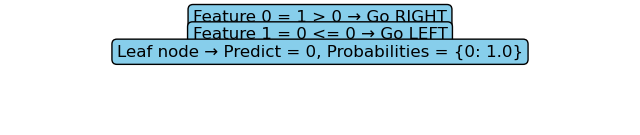

In [25]:
import matplotlib.pyplot as plt

def plot_decision_path(tree, x):
    
    path = []
    node = tree
    
    # Traverse tree to find the path for the sample
    while "label" not in node:
        feature = node["feature"]
        value = node["value"]
        
        if is_missing(x[feature]):
            # Handle missing: go to majority branch
            if len(node["left"]["probability"]) >= len(node["right"]["probability"]):
                node = node["left"]
                path.append(f"Feature {feature} is missing → Go LEFT (majority branch)")
            else:
                node = node["right"]
                path.append(f"Feature {feature} is missing → Go RIGHT (majority branch)")
        elif x[feature] <= value:
            node = node["left"]
            path.append(f"Feature {feature} = {x[feature]} <= {value} → Go LEFT")
        else:
            node = node["right"]
            path.append(f"Feature {feature} = {x[feature]} > {value} → Go RIGHT")
    
    # Add leaf prediction
    path.append(f"Leaf node → Predict = {node['label']}, Probabilities = {node['probability']}")
    
    # Plot using matplotlib
    plt.figure(figsize=(8, len(path)*0.5))
    for i, step in enumerate(path):
        plt.text(0.5, 1 - i*0.15, step, fontsize=12, ha='center', va='top',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="skyblue", edgecolor="black"))
    
    plt.axis("off")
    plt.show()

sample = X_test[0]

# Plot the decision path for this sample
plot_decision_path(tree_entropy, sample)

### 25. Save the tree structure to JSON and reload it for prediction.

In [32]:
import json
def save_tree_to_json(tree,filename="tree.json"):
    with open(filename,"w") as f:
        json.dump(tree,f,indent=4)
    print(f"Tree had been saved to {filename}")
def load_tree_from_json(filename="tree.json"):
    with open(filename ,"r") as f:
        tree = json.load(f)
    print(f"Tree has been loaded to {filename}")
    return tree

save_tree_to_json(tree_gini,"tree_gini.json")
loaded_tree = load_tree_from_json("tree_gini.json")
sample = X_test[4]

# Predict using loaded tree
predicted_label = predict(loaded_tree, sample)

print("Predicted label:", predicted_label)


Tree had been saved to tree_gini.json
Tree has been loaded to tree_gini.json
Predicted label: 1


In [35]:
import json


# 1. Save the trained tree to JSON
def save_tree_to_json(tree, filename="tree.json"):
    with open(filename, "w") as f:
        json.dump(tree, f, indent=4)
    print(f"Tree saved to {filename}")


# 2. Load the tree from JSON
def load_tree_from_json(filename="tree.json"):
    with open(filename, "r") as f:
        tree = json.load(f)
    print(f"Tree loaded from {filename}")
    return tree


# Example usage:

# Assume tree_entropy is your trained tree from previous build_tree()
save_tree_to_json(tree_entropy, "tree_entropy.json")

# Load the tree back
loaded_tree = load_tree_from_json("tree_entropy.json")

# Pick a sample from test set
sample = X_test[4]

# Predict using loaded tree
predicted_label = predict(loaded_tree, sample)

print("Predicted label:", predicted_label)


# Predict multiple samples if needed
X= X_test[:4]
def predict_multiple_json(tree, X):
    return [predict(tree, x) for x in X]

predictions = predict_multiple_json(loaded_tree, X_test)


Tree saved to tree_entropy.json
Tree loaded from tree_entropy.json
Predicted label: 0
